<a href="https://colab.research.google.com/github/dharun31-art/ECG-Analysis/blob/main/ECG_Analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import random

# Path to your dataset folder
dataset_path = "/content/drive/MyDrive/ECG dataset"
output_path = "/content/drive/MyDrive/ECG_split"

# Train-Test split ratio
train_ratio = 0.8

# Create train and test folders
for split in ["train", "test"]:
    for category in os.listdir(dataset_path):
        os.makedirs(os.path.join(output_path, split, category), exist_ok=True)

# Move images into train and test folders
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)
    images = os.listdir(category_path)
    random.shuffle(images)

    split_idx = int(len(images) * train_ratio)
    train_images, test_images = images[:split_idx], images[split_idx:]

    # Move to train folder
    for img in train_images:
        shutil.copy(os.path.join(category_path, img), os.path.join(output_path, "train", category, img))

    # Move to test folder
    for img in test_images:
        shutil.copy(os.path.join(category_path, img), os.path.join(output_path, "test", category, img))

print("✅ Dataset split successfully into 'train' and 'test' folders!")


✅ Dataset split successfully into 'train' and 'test' folders!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.12.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

In [ ]:
!pip install tensorflow-addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 12.5 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.2
    Uninstalling typeguard-4.4.2:
      Successfully uninstalled typeguard-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
!pip install tensorflow==2.12 keras==2.12 --no-cache-dir

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 182.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 163.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 161.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 95.7 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
   

In [ ]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

train_data = datagen.flow_from_directory(
    "/content/drive/MyDrive/ECG_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

test_data = datagen.flow_from_directory(
    "/content/drive/MyDrive/ECG_split/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 923 images belonging to 4 classes.
Found 462 images belonging to 4 classes.


In [ ]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)  # 4 classes: Normal, Abnormal, MI, Previous MI

model = Model(inputs=base_model.input, outputs=output)


94765736/94765736 [==============================] - 0s 0us/step


In [ ]:
class_weights = {
    0: 1.0,  # Normal
    1: 2.0,  # Abnormal
    2: 1.0,  # MI
    3: 2.5   # 🔥 Increase weight for "Previous MI"
}

In [ ]:
loss_fn = tfa.losses.SigmoidFocalCrossEntropy(alpha=0.25, gamma=2.0)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data,
    class_weight=class_weights  # Apply class weights
)
# Save the trained model after training
model.save("your_model.h5")

Epoch 1/5
29/29 [==============================] - 911s 31s/step - loss: 0.3223 - accuracy: 0.4074 - val_loss: 0.4473 - val_accuracy: 0.2078
Epoch 2/5
29/29 [==============================] - 915s 32s/step - loss: 0.3096 - accuracy: 0.3965 - val_loss: 0.5644 - val_accuracy: 0.1861
Epoch 3/5
29/29 [==============================] - 916s 32s/step - loss: 0.3040 - accuracy: 0.4095 - val_loss: 0.4437 - val_accuracy: 0.1926
Epoch 4/5
29/29 [==============================] - 910s 31s/step - loss: 0.3086 - accuracy: 0.4128 - val_loss: 0.3283 - val_accuracy: 0.2554
Epoch 5/5
29/29 [==============================] - 914s 31s/step - loss: 0.3107 - accuracy: 0.4030 - val_loss: 0.2419 - val_accuracy: 0.2511


In [ ]:
y_true = test_data.classes
y_pred = model.predict(test_data)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

15/15 [==============================] - 118s 7s/step
              precision    recall  f1-score   support

           0       0.19      0.36      0.25       115
           1       0.25      0.50      0.33       115
           2       0.38      0.04      0.07       145
           3       0.00      0.00      0.00        87

    accuracy                           0.23       462
   macro avg       0.20      0.23      0.16       462
weighted avg       0.23      0.23      0.17       462

[[41 74  0  0]
 [52 58  5  0]
 [77 61  6  1]
 [41 41  5  0]]


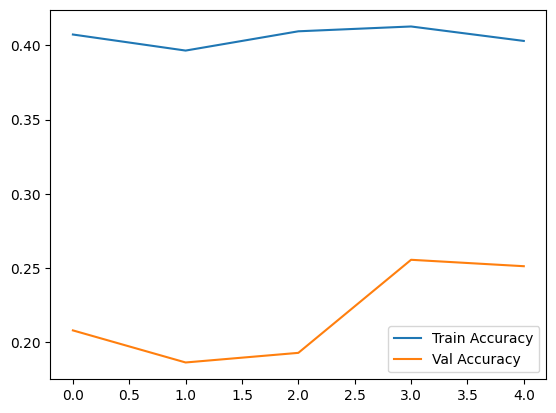

In [ ]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.show()

1/1 [==============================] - 1s 572ms/step
DEBUG: Predicted Index = 2, Predicted Class = Previous MI
DEBUG: Bar Colors = ['gray', 'gray', 'orange', 'gray']
🩺 **Diagnosis**: Previous MI
🎨 **Severity Level**: orange
📌 **Guidance**: Consult a doctor for follow-up tests.


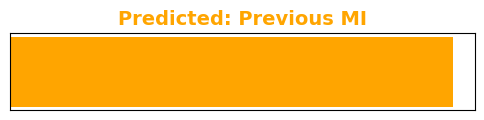

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Define severity mapping
severity_mapping = {
    "Normal": ("Green", "No immediate action required."),
    "Abnormal Heartbeat": ("Yellow", "Consult a cardiologist for further evaluation."),
    "Previous MI": ("Orange", "Consult a doctor for follow-up tests."),
    "Myocardial Infarction (MI)": ("Red", "IMMEDIATE medical attention required!"),
}

# Class names (Ensure the order matches your model output)
class_names = ["Normal", "Abnormal Heartbeat", "Previous MI", "Myocardial Infarction (MI)"]

def predict_ecg(image_path, model):
    # Load and preprocess image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict class
    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]

    # Get severity color and guidance
    severity_color, guidance = severity_mapping[predicted_class]

    # Debugging: Print prediction info
    print(f"DEBUG: Predicted Index = {predicted_index}, Predicted Class = {predicted_class}")

    # Define all colors as gray first
    colors = ["gray"] * len(class_names)

    # Assign the correct color to the predicted class
    severity_colors = ["green", "yellow", "orange", "red"]  # Ensure the order matches class_names
    colors[predicted_index] = severity_colors[predicted_index]  # Highlight correct color

    # Debugging: Print assigned bar colors
    print(f"DEBUG: Bar Colors = {colors}")

    # Plot severity level
    fig, ax = plt.subplots(figsize=(6, 1))
    ax.barh(["Severity"], [1], color=colors[predicted_index], height=0.4)  # Fix here

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Predicted: {predicted_class}", fontsize=14, weight="bold", color=severity_color)

    # Display text-based prediction results
    print(f"🩺 **Diagnosis**: {predicted_class}")
    print(f"🎨 **Severity Level**: {severity_color}")
    print(f"📌 **Guidance**: {guidance}")

    plt.show()

# Example Usage
image_path = "/content/drive/MyDrive/ECG_split/test/Previous MI/PMI(10).jpg
"
predict_ecg(image_path, model)


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load and preprocess the image
img = image.load_img(image_path, target_size=(224, 224))  # Adjust size if needed
img_array = image.img_to_array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions

# Get model predictions
prediction_probs = model.predict(img_array)[0]  # Extract probabilities

# Define class names (replace with your actual class names)
class_names = ["Normal", "Abnormal Heartbeat", "Previous MI", "Myocardial Infarction"]

# Print prediction probabilities
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {prediction_probs[i]:.4f}")


1/1 [==============================] - 0s 370ms/step
Normal: 0.2429
Abnormal Heartbeat: 0.1083
Previous MI: 0.3349
Myocardial Infarction: 0.3139


In [ ]:
import numpy as np

# Assuming 'prediction_probs' contains the output probabilities from the model
class_names = ["Normal", "Abnormal Heartbeat", "Previous MI", "Myocardial Infarction"]
threshold = 0.30  # Adjust based on model performance

max_prob = np.max(prediction_probs)
predicted_index = np.argmax(prediction_probs)

if max_prob < threshold:
    print("⚠️ Uncertain Prediction: Consider further evaluation or additional testing.")
else:
    predicted_class = class_names[predicted_index]
    print(f"✅ Predicted Class: {predicted_class} with confidence {max_prob:.2f}")


✅ Predicted Class: Previous MI with confidence 0.33


In [ ]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model("/content/your_model.h5")  # Replace with your actual model file

# Define the class labels
class_labels = ["Normal", "Abnormal Heartbeat", "Previous MI", "Myocardial Infarction"]

# Define confidence threshold
THRESHOLD = 0.30  # Adjust based on performance

def predict_ecg(image_path, model):
    """Function to predict ECG class with threshold-based handling."""
    # Load and preprocess the image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
    img = cv2.resize(img, (224, 224))  # Resize to model input size
    img = img / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)  # Expand dimensions for batch input
    img = np.expand_dims(img, axis=-1)  # Add channel dimension if needed

    # Make prediction
    predictions = model.predict(img)[0]  # Get the first sample prediction

    # Map predictions to class labels
    prediction_dict = {class_labels[i]: predictions[i] for i in range(len(class_labels))}

    # Get top predicted class
    predicted_class = max(prediction_dict, key=prediction_dict.get)
    max_prob = prediction_dict[predicted_class]

    # Sort predictions to find the second most probable class
    sorted_preds = sorted(prediction_dict.items(), key=lambda x: x[1], reverse=True)
    top_2_classes = sorted_preds[:2]

    # 🛠 Apply Threshold-Based Handling
    if max_prob >= THRESHOLD:
        result = f"✅ Predicted Class: {predicted_class} with confidence {max_prob:.2f}"
    elif top_2_classes[1][1] >= 0.25:  # If second highest is also significant
        result = (f"⚠️ Uncertain Prediction: Possible Conditions - "
                  f"{top_2_classes[0][0]} ({top_2_classes[0][1]:.2f}), "
                  f"{top_2_classes[1][0]} ({top_2_classes[1][1]:.2f})")
    else:
        result = "⚠️ Uncertain Prediction: Consider further evaluation or additional testing."

    print(result)  # Print to console
    return result

# Example Usage
image_path = "/content/drive/MyDrive/ECG_split/test/Abnormal Heartbeat/HB(1).jpg"  # Replace with your actual image path
predict_ecg(image_path, model)


In [ ]:
import os

train_dir = "/content/drive/MyDrive/ECG_split/train"
test_dir = "/content/drive/MyDrive/ECG_split/test"

def count_images(directory):
    total_count = 0
    class_counts = {}

    for category in os.listdir(directory):
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            num_images = len([f for f in os.listdir(category_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[category] = num_images
            total_count += num_images

    return total_count, class_counts

train_total, train_class_counts = count_images(train_dir)
test_total, test_class_counts = count_images(test_dir)

print(f"✅ Total images in TRAIN: {train_total}")
print("📂 Images per class in TRAIN:", train_class_counts)

print(f"✅ Total images in TEST: {test_total}")
print("📂 Images per class in TEST:", test_class_counts)


✅ Total images in TRAIN: 923
📂 Images per class in TRAIN: {'Normal': 283, 'Previous MI': 172, 'Abnormal Heartbeat': 230, 'Myocardial Infarction (MI)': 238}
✅ Total images in TEST: 462
📂 Images per class in TEST: {'Normal': 145, 'Previous MI': 87, 'Abnormal Heartbeat': 115, 'Myocardial Infarction (MI)': 115}


In [ ]:
#Load Pretrained ResNet50
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
#Freeze Initial Layers
for layer in base_model.layers[:143]:  # Freeze layers 0 to 143
    layer.trainable = False


In [ ]:
#Add Custom Classification Head
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D

x = base_model.output
x = GlobalAveragePooling2D()(x)  # Converts feature maps into a vector
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)  # 4 classes: Normal, Abnormal HB, Previous MI, MI

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
#Compile and Train Only the Top Layers
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_generator, validation_data=val_generator, epochs=10)


In [ ]:
#Gradually Unfreeze More Layers (Fine-Tuning)
for layer in base_model.layers[100:]:  # Unfreeze from layer 100 onwards
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_generator, validation_data=val_generator, epochs=10)
